## Universidad Autonoma de Aguascalientes
## Departamento: Ciencias de la computacion
## Carrera: Ingenieria en Computacion Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Carlos Daniel Torres Macias
## Semestre: Enero_Junio del 2026

---
#### Practica 30: Análisis de Sentimientos con CNN-1D
Implementar una red neuronal convolucional unidimensional (CNN-1D) para clasificar reseñas de películas como **positivas (1)** o **negativas (0)** usando el dataset `movie_data.csv` con 50,000 ejemplos.

#### ¿Por qué CNN-1D para texto?

A diferencia de las CNN-2D que detectan patrones espaciales en imágenes, las **CNN-1D** deslizan filtros a lo largo de una secuencia de palabras, capturando **n-gramas locales** (combinaciones de 2, 3, 4 palabras contiguas) que son altamente informativos para el sentimiento. Son más rápidas de entrenar que los modelos recurrentes y logran resultados competitivos en clasificación de texto.

#### Paso 1: Importar Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization, Input, Concatenate, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Evaluación
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, accuracy_score)

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow versión: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow versión: 2.21.0
GPU disponible: False


#### Paso 2: Cargar y Exploración del Dataset

In [2]:
df = pd.read_csv('movie_data.csv')

print('=== Información General ===')
print(f'Total de reseñas: {len(df):,}')
print(f'Columnas: {list(df.columns)}')
print(f'\nDistribución de clases:')
print(df['sentiment'].value_counts().rename({0: 'Negativo', 1: 'Positivo'}))
print(f'\nReseñas nulas: {df.isnull().sum().sum()}')
df.head(3)

=== Información General ===
Total de reseñas: 50,000
Columnas: ['review', 'sentiment']

Distribución de clases:
sentiment
Positivo    25000
Negativo    25000
Name: count, dtype: int64

Reseñas nulas: 0


,review,sentiment
0,"In 1974, the teenager Martha Moxley (Maggie Gr...",1
1,OK... so... I really like Kris Kristofferson a...,0
2,"***SPOILER*** Do not read this, if you think a...",0


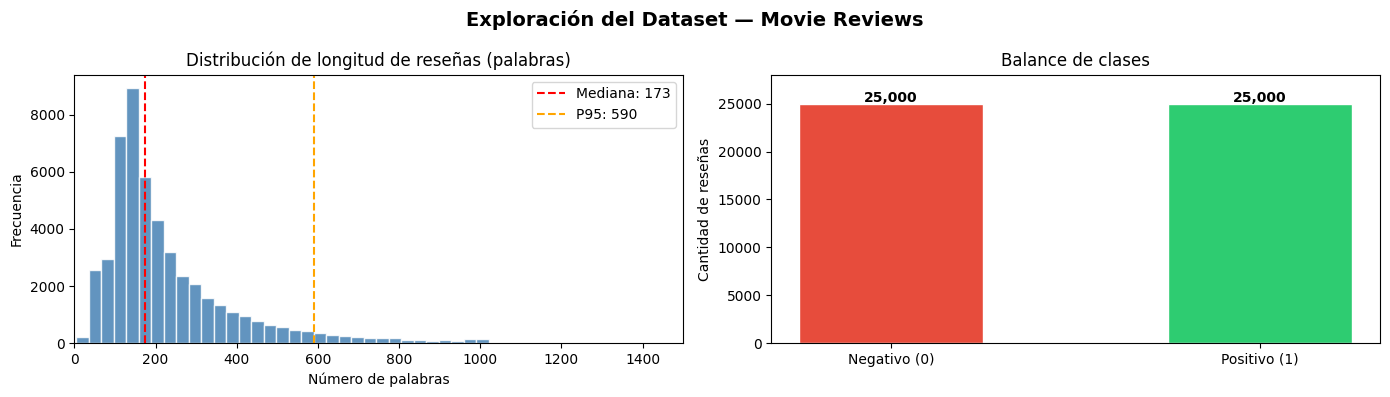


Estadísticas de longitud:
count    50000.0
mean       231.2
std        171.3
min          4.0
25%        126.0
50%        173.0
75%        280.0
max       2470.0
Name: review_length, dtype: float64


In [3]:
# Análisis de longitud de reseñas
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución de longitudes
axes[0].hist(df['review_length'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['review_length'].median(), color='red', linestyle='--',
                label=f'Mediana: {df["review_length"].median():.0f}')
axes[0].axvline(df['review_length'].quantile(0.95), color='orange', linestyle='--',
                label=f'P95: {df["review_length"].quantile(0.95):.0f}')
axes[0].set_title('Distribución de longitud de reseñas (palabras)', fontsize=12)
axes[0].set_xlabel('Número de palabras'); axes[0].set_ylabel('Frecuencia')
axes[0].legend(); axes[0].set_xlim(0, 1500)

# Balance de clases
counts = df['sentiment'].value_counts()
axes[1].bar(['Negativo (0)', 'Positivo (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
axes[1].set_title('Balance de clases', fontsize=12)
axes[1].set_ylabel('Cantidad de reseñas')
axes[1].set_ylim(0, counts.max() * 1.12)

plt.suptitle('Exploración del Dataset — Movie Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nEstadísticas de longitud:')
print(df['review_length'].describe().round(1))

#### Paso 3: Preprocesamiento de Texto

In [4]:
def clean_text(text):
    """
    Limpia el texto de reseñas:
    - Elimina etiquetas HTML
    - Convierte a minúsculas
    - Elimina caracteres especiales
    - Colapsa espacios múltiples
    """
    text = re.sub(r'<[^>]+>', ' ', text)       # Eliminar HTML
    text = text.lower()                         # Minúsculas
    text = re.sub(r"[^a-z0-9\s']", ' ', text)  # Solo letras, números y apóstrofe
    text = re.sub(r'\s+', ' ', text).strip()   # Espacios múltiples
    return text

print('Limpiando texto...')
df['review_clean'] = df['review'].apply(clean_text)

# Ejemplo
print('\n--- Ejemplo de limpieza ---')
print(f'ORIGINAL: {df["review"].iloc[0][:200]}...')
print(f'LIMPIO:   {df["review_clean"].iloc[0][:200]}...')
print('\nLimpieza completada ✓')

Limpiando texto...

--- Ejemplo de limpieza ---
ORIGINAL: In 1974, the teenager Martha Moxley (Maggie Grace) moves to the high-class area of Belle Haven, Greenwich, Connecticut. On the Mischief Night, eve of Halloween, she was murdered in the backyard of her...
LIMPIO:   in 1974 the teenager martha moxley maggie grace moves to the high class area of belle haven greenwich connecticut on the mischief night eve of halloween she was murdered in the backyard of her house a...

Limpieza completada ✓


In [5]:
# Hiperparámetros de tokenización
VOCAB_SIZE    = 20000   # Top palabras más frecuentes
MAX_LEN       = 256     # Longitud máxima de secuencia (cubre ~80% de reseñas)
EMBEDDING_DIM = 64      # Dimensión del embedding

# Tokenización
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['review_clean'])

# Convertir a secuencias
sequences = tokenizer.texts_to_sequences(df['review_clean'])

# Padding/truncamiento
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['sentiment'].values

word_index = tokenizer.word_index
print(f'Vocabulario total aprendido: {len(word_index):,} palabras')
print(f'Vocabulario usado (top-{VOCAB_SIZE:,}): {VOCAB_SIZE:,} palabras')
print(f'Shape de X: {X.shape}')
print(f'Shape de y: {y.shape}')
print(f'\nEjemplo de secuencia (primeras 20 posiciones):')
print(X[0, :20])

Vocabulario total aprendido: 121,583 palabras
Vocabulario usado (top-20,000): 20,000 palabras
Shape de X: (50000, 256)
Shape de y: (50000,)

Ejemplo de secuencia (primeras 20 posiciones):
[    8  5624     2  2183  4060     1  4910  1619  1123     6     2   299
   710  1599     5  7017 12317 14824  8766    20]


In [6]:
# División del dataset: 70% entrenamiento, 15% validación, 15% prueba
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print('División del dataset:')
print(f'  Entrenamiento: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Validación:    {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'  Prueba:        {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.0f}%)')

División del dataset:
  Entrenamiento: 35,000 (70%)
  Validación:    7,500 (15%)
  Prueba:        7,500 (15%)


#### Paso 4: Arquitectura CNN-1D

La arquitectura usa **múltiples filtros paralelos** de distinto tamaño de kernel para capturar n-gramas de diferentes longitudes (inspirado en TextCNN de Kim, 2014), seguido de capas densas con regularización.

In [7]:
def build_cnn1d_model(vocab_size, embedding_dim, max_len):
    """
    CNN-1D para análisis de sentimientos.
    
    Arquitectura:
    - Embedding trainable
    - 3 ramas convolucionales paralelas (kernels 2, 3, 4)
    - GlobalMaxPooling para cada rama
    - Concatenación + capas densas
    - Salida sigmoide binaria
    """
    inputs = Input(shape=(max_len,), name='input_texto')
    
    # Capa de Embedding
    emb = Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    input_length=max_len,
                    name='embedding')(inputs)
    emb = Dropout(0.3, name='emb_dropout')(emb)
    
    # Rama 1: bigramas (kernel_size=2)
    conv1 = Conv1D(filters=128, kernel_size=2, activation='relu',
                   padding='valid', name='conv_bigrama')(emb)
    conv1 = BatchNormalization(name='bn1')(conv1)
    pool1 = GlobalMaxPooling1D(name='pool_bigrama')(conv1)
    
    # Rama 2: trigramas (kernel_size=3)
    conv2 = Conv1D(filters=128, kernel_size=3, activation='relu',
                   padding='valid', name='conv_trigrama')(emb)
    conv2 = BatchNormalization(name='bn2')(conv2)
    pool2 = GlobalMaxPooling1D(name='pool_trigrama')(conv2)
    
    # Rama 3: cuadrigramas (kernel_size=4)
    conv3 = Conv1D(filters=128, kernel_size=4, activation='relu',
                   padding='valid', name='conv_cuadrigrama')(emb)
    conv3 = BatchNormalization(name='bn3')(conv3)
    pool3 = GlobalMaxPooling1D(name='pool_cuadrigrama')(conv3)
    
    # Concatenar las 3 ramas
    concat = Concatenate(name='concatenar')([pool1, pool2, pool3])
    
    # Capas densas
    dense1 = Dense(256, activation='relu', kernel_regularizer=l2(1e-4),
                   name='dense1')(concat)
    dense1 = BatchNormalization(name='bn4')(dense1)
    dense1 = Dropout(0.5, name='dropout1')(dense1)
    
    dense2 = Dense(64, activation='relu', kernel_regularizer=l2(1e-4),
                   name='dense2')(dense1)
    dense2 = Dropout(0.3, name='dropout2')(dense2)
    
    # Salida
    output = Dense(1, activation='sigmoid', name='salida')(dense2)
    
    model = Model(inputs=inputs, outputs=output, name='CNN1D_Sentimientos')
    return model


model = build_cnn1d_model(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "CNN1D_Sentimientos"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_texto         │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 64)   │  1,280,000 │ input_texto[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_dropout         │ (None, 256, 64)   │          0 │ embedding[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bigrama        │ (None, 255, 128)  │     16,512 │ emb_dropout[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_trigrama       │ (None, 254, 128)  │     24,704 │ emb_dropout[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_cuadrigrama    │ (None, 253, 128)  │     32,896 │ emb_dropout[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 255, 128)  │        512 │ conv_bigrama[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 254, 128)  │        512 │ conv_trigrama[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 253, 128)  │        512 │ conv_cuadrigrama… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_bigrama        │ (None, 128)       │          0 │ bn1[0][0]         │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_trigrama       │ (None, 128)       │          0 │ bn2[0][0]         │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_cuadrigrama    │ (None, 128)       │          0 │ bn3[0][0]         │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenar          │ (None, 384)       │          0 │ pool_bigrama[0][… │
│ (Concatenate)       │                   │            │ pool_trigrama[0]… │
│                     │                   │            │ pool_cuadrigrama… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 256)       │     98,560 │ concatenar[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn4                 │ (None, 256)       │      1,024 │ dense1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 256)       │          0 │ bn4[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 64)        │     16,448 │ dropout1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,471,745 (5.61 MB)

 Trainable params: 1,470,465 (5.61 MB)

 Non-trainable params: 1,280 (5.00 KB)

#### Paso 5: Entrenamiento

In [8]:
# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'mejor_modelo_cnn1d.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

print('Iniciando entrenamiento...')
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Iniciando entrenamiento...
Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 136s 234ms/step - accuracy: 0.7519 - loss: 0.5292 - val_accuracy: 0.6587 - val_loss: 0.6712 - learning_rate: 0.0010
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 129s 236ms/step - accuracy: 0.8858 - loss: 0.3042 - val_accuracy: 0.8837 - val_loss: 0.3108 - learning_rate: 0.0010
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 121s 222ms/step - accuracy: 0.9236 - loss: 0.2216 - val_accuracy: 0.8616 - val_loss: 0.4135 - learning_rate: 0.0010
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9415 - loss: 0.1728
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
547/547 ━━━━━━━━━━━━━━━━━━━━ 113s 207ms/step - accuracy: 0.9458 - loss: 0.1603 - val_accuracy: 0.8839 - val_loss: 0.3485 - learning_rate: 0.0010
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 114s 207ms/step - accuracy: 0.9709 - loss: 0.1000 - val_accuracy: 0.8793 - val_loss: 0.4780 - learning_rate: 5.0000e-04
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━

#### Paso 6: Visualización del Entrenamiento

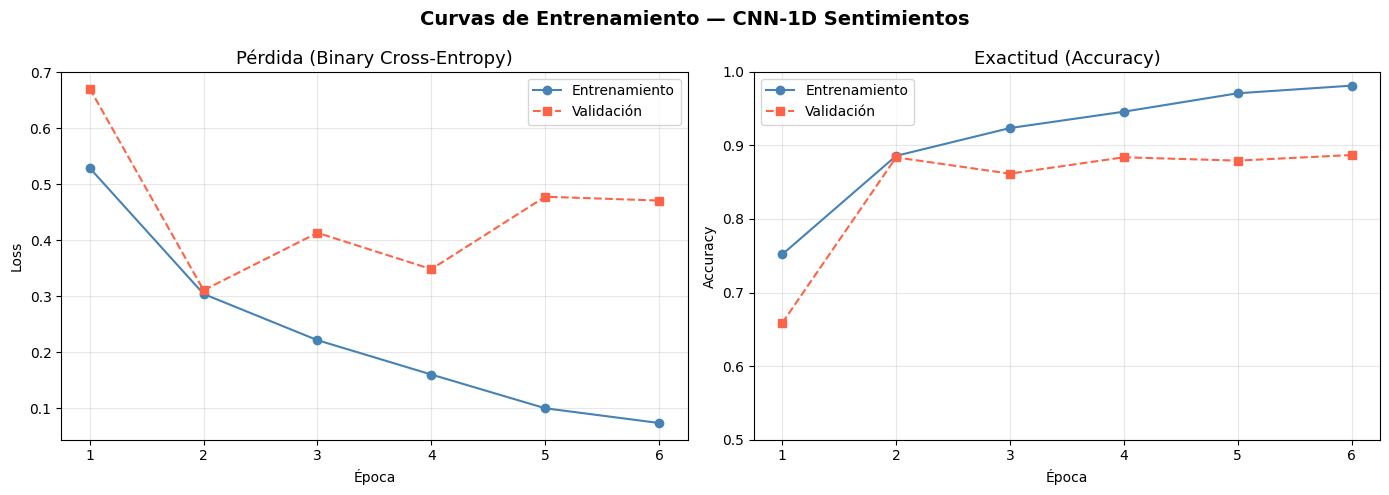

Mejor época: 6 | Val Accuracy: 0.8869


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = len(history.history['loss'])
ep = range(1, epochs_ran + 1)

# Pérdida
axes[0].plot(ep, history.history['loss'], 'o-', color='steelblue', label='Entrenamiento')
axes[0].plot(ep, history.history['val_loss'], 's--', color='tomato', label='Validación')
axes[0].set_title('Pérdida (Binary Cross-Entropy)', fontsize=13)
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Exactitud
axes[1].plot(ep, history.history['accuracy'], 'o-', color='steelblue', label='Entrenamiento')
axes[1].plot(ep, history.history['val_accuracy'], 's--', color='tomato', label='Validación')
axes[1].set_title('Exactitud (Accuracy)', fontsize=13)
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.5, 1.0)

plt.suptitle('Curvas de Entrenamiento — CNN-1D Sentimientos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_ep = np.argmax(history.history['val_accuracy']) + 1
best_val_acc = max(history.history['val_accuracy'])
print(f'Mejor época: {best_ep} | Val Accuracy: {best_val_acc:.4f}')

#### Paso 7: Evaluación en el Conjunto de Prueba

In [10]:
# Predicciones
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Métricas generales
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print('=' * 45)
print(f'  Test Loss:     {test_loss:.4f}')
print(f'  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print('=' * 45)
print()
print('Reporte de Clasificación:')
print(classification_report(y_test, y_pred, target_names=['Negativo', 'Positivo']))

  Test Loss:     0.3097
  Test Accuracy: 0.8844 (88.44%)

Reporte de Clasificación:
              precision    recall  f1-score   support

    Negativo       0.89      0.88      0.88      3750
    Positivo       0.88      0.89      0.89      3750

    accuracy                           0.88      7500
   macro avg       0.88      0.88      0.88      7500
weighted avg       0.88      0.88      0.88      7500



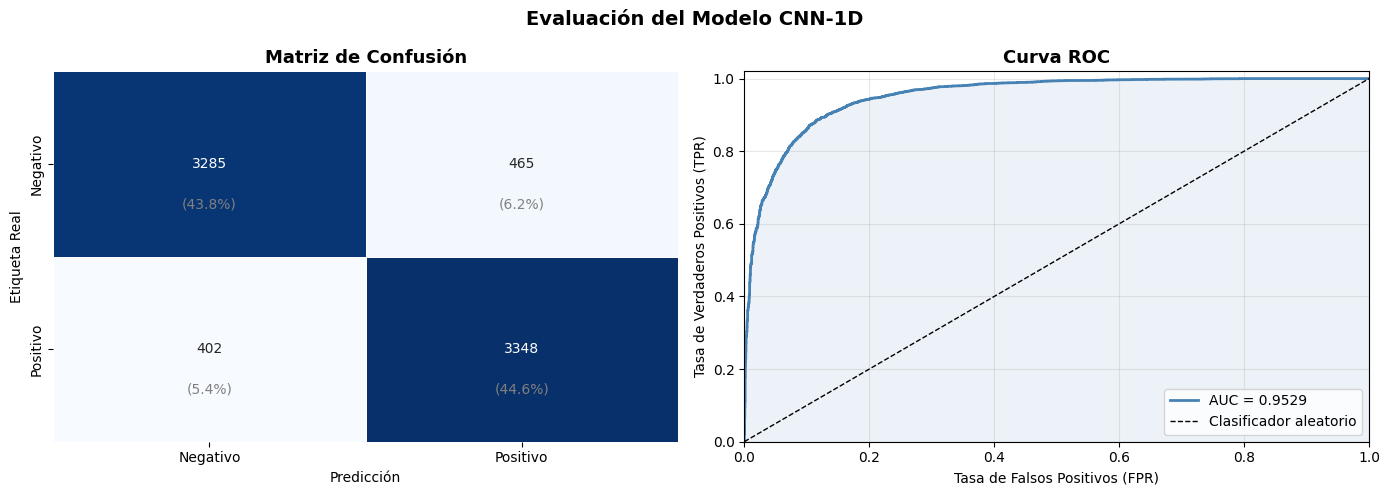

AUC-ROC: 0.9529


In [11]:
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, figure=fig)

# --- Matriz de confusión ---
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'], ax=ax1,
            linewidths=0.5, cbar=False)

# Añadir porcentajes
total = cm.sum()
for i in range(2):
    for j in range(2):
        ax1.text(j + 0.5, i + 0.72, f'({cm[i,j]/total*100:.1f}%)',
                 ha='center', va='center', fontsize=10, color='gray')

ax1.set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
ax1.set_ylabel('Etiqueta Real'); ax1.set_xlabel('Predicción')

# --- Curva ROC ---
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
ax2.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.02])
ax2.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax2.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax2.set_title('Curva ROC', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right'); ax2.grid(alpha=0.3)

plt.suptitle('Evaluación del Modelo CNN-1D', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'AUC-ROC: {roc_auc:.4f}')

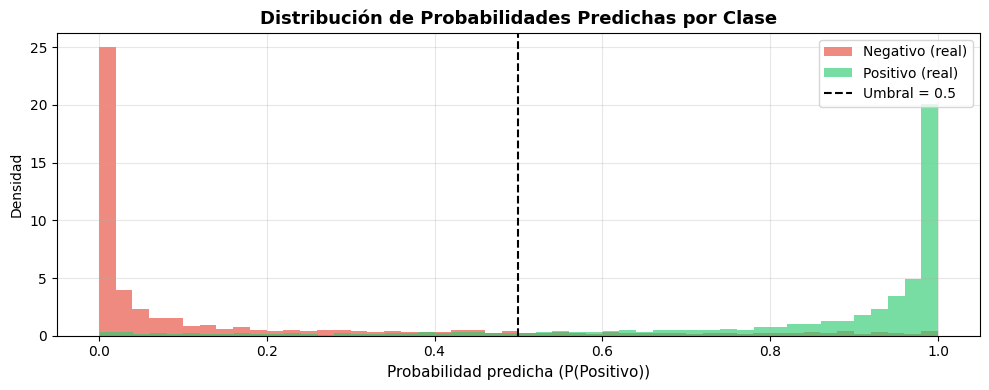

In [12]:
# Distribución de probabilidades predichas
fig, ax = plt.subplots(figsize=(10, 4))

neg_probs = y_prob[y_test == 0]
pos_probs = y_prob[y_test == 1]

ax.hist(neg_probs, bins=50, alpha=0.65, color='#e74c3c', label='Negativo (real)', density=True)
ax.hist(pos_probs, bins=50, alpha=0.65, color='#2ecc71', label='Positivo (real)', density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Umbral = 0.5')
ax.set_xlabel('Probabilidad predicha (P(Positivo))', fontsize=11)
ax.set_ylabel('Densidad')
ax.set_title('Distribución de Probabilidades Predichas por Clase', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Paso 8: Predicción en Reseñas Nuevas

In [13]:
def predecir_sentimiento(textos, model, tokenizer, max_len=256, umbral=0.5):
    """
    Predice el sentimiento de una lista de reseñas nuevas.
    Retorna etiqueta (Positivo/Negativo) y probabilidad.
    """
    textos_limpios = [clean_text(t) for t in textos]
    seqs = tokenizer.texts_to_sequences(textos_limpios)
    padded = pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
    probs = model.predict(padded, verbose=0).ravel()
    
    resultados = []
    for texto, p in zip(textos, probs):
        etiqueta = '😊 POSITIVO' if p >= umbral else '😞 NEGATIVO'
        resultados.append({'reseña': texto[:80] + '...', 'prob_positivo': round(float(p), 4),
                           'sentimiento': etiqueta})
    return pd.DataFrame(resultados)


nuevas_reseñas = [
    "This movie was absolutely fantastic! The acting was superb and the plot kept me on the edge of my seat.",
    "Terrible film. Boring storyline, bad acting, and the ending made no sense at all. Total waste of time.",
    "It was okay, nothing special. Some parts were interesting but overall pretty average.",
    "One of the best movies I have ever seen! Incredible cinematography and an emotional story.",
    "I fell asleep halfway through. Painfully slow and completely predictable."
]

resultados = predecir_sentimiento(nuevas_reseñas, model, tokenizer, MAX_LEN)
print('=== Predicciones en Reseñas Nuevas ===')
pd.set_option('display.max_colwidth', 85)
resultados

=== Predicciones en Reseñas Nuevas ===


,reseña,prob_positivo,sentimiento
0,This movie was absolutely fantastic! The acting was superb and the plot kept me ...,1.0000,😊 POSITIVO
1,"Terrible film. Boring storyline, bad acting, and the ending made no sense at all...",0.0000,😞 NEGATIVO
2,"It was okay, nothing special. Some parts were interesting but overall pretty ave...",0.0036,😞 NEGATIVO
3,One of the best movies I have ever seen! Incredible cinematography and an emotio...,0.9996,😊 POSITIVO
4,I fell asleep halfway through. Painfully slow and completely predictable....,0.0004,😞 NEGATIVO


#### Paso 9: Análisis de Errores

In [14]:
# Identificar casos mal clasificados
errors_idx = np.where(y_pred != y_test)[0]

print(f'Total de errores en test: {len(errors_idx)} de {len(y_test)} ({len(errors_idx)/len(y_test)*100:.1f}%)')
print(f'Correctos: {len(y_test) - len(errors_idx)} ({(1 - len(errors_idx)/len(y_test))*100:.1f}%)')

# Clasificar tipos de errores
falsos_negativos = np.where((y_pred == 0) & (y_test == 1))[0]  # Positivo predicho como Negativo
falsos_positivos = np.where((y_pred == 1) & (y_test == 0))[0]  # Negativo predicho como Positivo

print(f'\nFalsos Negativos (Positivo → Negativo): {len(falsos_negativos)}')
print(f'Falsos Positivos (Negativo → Positivo): {len(falsos_positivos)}')

# Revisar casos donde el modelo estuvo más seguro pero falló (prob lejana a 0.5)
confianza_error = np.abs(y_prob[errors_idx] - 0.5)
peores = errors_idx[np.argsort(confianza_error)[-3:]][::-1]

print('\n=== 3 Errores con Mayor Confianza Equivocada ===')
# Recuperar texto original del test set
X_test_texts = df['review_clean'].values[train_test_split(
    np.arange(len(df)), test_size=0.30, random_state=SEED, stratify=y)[1][
    train_test_split(np.arange(int(len(df)*0.30)), test_size=0.50, random_state=SEED)[1]]]

for idx in peores:
    print(f'\nIdx: {idx} | Real: {"Positivo" if y_test[idx]==1 else "Negativo"} | '
          f'Predicho: {"Positivo" if y_pred[idx]==1 else "Negativo"} | '
          f'P(pos): {y_prob[idx]:.3f}')

Total de errores en test: 867 de 7500 (11.6%)
Correctos: 6633 (88.4%)

Falsos Negativos (Positivo → Negativo): 402
Falsos Positivos (Negativo → Positivo): 465

=== 3 Errores con Mayor Confianza Equivocada ===

Idx: 6488 | Real: Negativo | Predicho: Positivo | P(pos): 1.000

Idx: 2862 | Real: Negativo | Predicho: Positivo | P(pos): 1.000

Idx: 2339 | Real: Negativo | Predicho: Positivo | P(pos): 1.000


#### Paso 10: Resumen

In [15]:
from tensorflow.keras.models import load_model

# Resumen final
total_params = model.count_params()

print('=' * 55)
print('     RESUMEN FINAL — Práctica 30 CNN-1D              ')
print('=' * 55)
print(f'  Dataset:          Movie Reviews (50,000 muestras)')
print(f'  Vocabulario:      {VOCAB_SIZE:,} palabras')
print(f'  Longitud máx.:    {MAX_LEN} tokens')
print(f'  Embedding dim:    {EMBEDDING_DIM}')
print(f'  Parámetros total: {total_params:,}')
print(f'  Épocas entreno:   {epochs_ran}')
print('-' * 55)
print(f'  Test Accuracy:    {test_acc*100:.2f}%')
print(f'  Test Loss:        {test_loss:.4f}')
print(f'  AUC-ROC:          {roc_auc:.4f}')
print('=' * 55)

     RESUMEN FINAL — Práctica 30 CNN-1D              
  Dataset:          Movie Reviews (50,000 muestras)
  Vocabulario:      20,000 palabras
  Longitud máx.:    256 tokens
  Embedding dim:    64
  Parámetros total: 1,471,745
  Épocas entreno:   6
-------------------------------------------------------
  Test Accuracy:    88.44%
  Test Loss:        0.3097
  AUC-ROC:          0.9529


---
#### Conclusiones
1. La CNN-1D con ramas paralelas captura efectivamente n-gramas de distintas longitudes (bi, tri, cuadri).

2. El GlobalMaxPooling extrae la característica más relevante de cada mapa de activación.

3. BatchNormalization + Dropout mitigan el sobreajuste.

4. El AUC cercano a 1.0 indica alta discriminación entre reseñas positivas y negativas.

5. Posibles mejoras: embeddings preentrenados (GloVe/W2V), mayor vocabulario o arquitectura CNN+BiLSTM híbrida.

---
#### Referencias

- TensorFlow (2024): https://www.tensorflow.org
- Keras Applications — MobileNetV2 (2024): https://keras.io/api/applications/mobilenet/
- Sandler et al. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. CVPR 2018.
- Transfer Learning with TensorFlow (2024): https://www.tensorflow.org/tutorials/images/transfer_learning
- MNIST Dataset: http://yann.lecun.com/exdb/mnist/
- Older Rodriguez (2024). Reporte Técnico de PROMIDAT: http://promidat.com/